1. Digital Engagement vs Transaction Count
Pearson correlation: 0.038


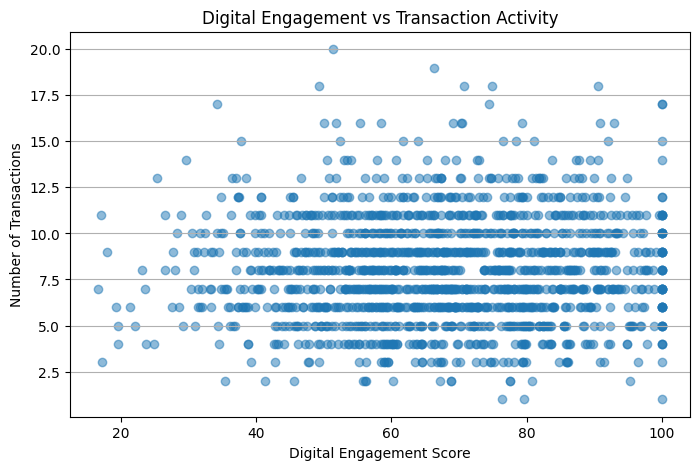


2. Digital Engagement vs Total Transaction Value
Pearson correlation: 0.024


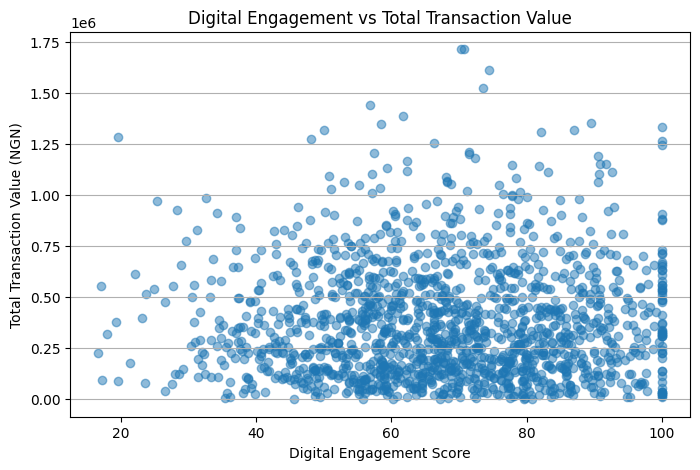


3. Customer-Level Correlation Matrix
                           Digital_Engagement_Score  Transaction_Count  \
Digital_Engagement_Score                      1.000              0.038   
Transaction_Count                             0.038              1.000   
Total_Transaction_Value                       0.024              0.503   
Average_Transaction_Value                    -0.007              0.036   

                           Total_Transaction_Value  Average_Transaction_Value  
Digital_Engagement_Score                     0.024                     -0.007  
Transaction_Count                            0.503                      0.036  
Total_Transaction_Value                      1.000                      0.817  
Average_Transaction_Value                    0.817                      1.000  

4. Transaction Amount by Risk Review Status
                  Transaction_Count  Average_Amount  Median_Amount
Risk_Review_Flag                                                  
No          

<Figure size 800x500 with 0 Axes>

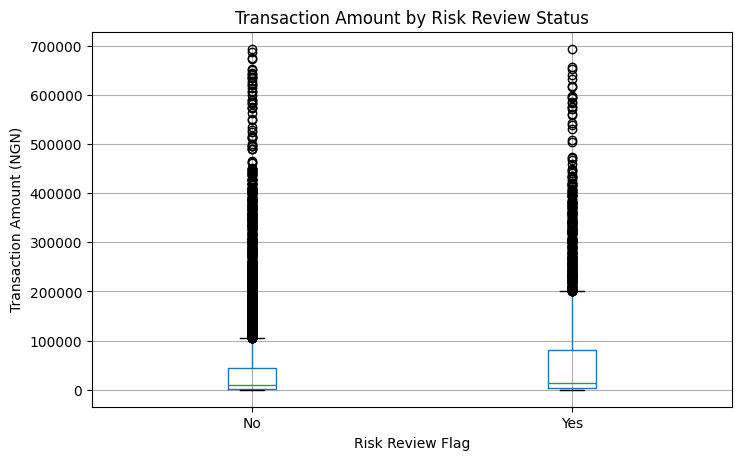


5. Risk Review Rate by Channel
Channel
Web           21.35
ATM           21.18
Mobile App    19.40
POS           18.35
USSD          17.32
Name: Risk_Review_Flag, dtype: float64


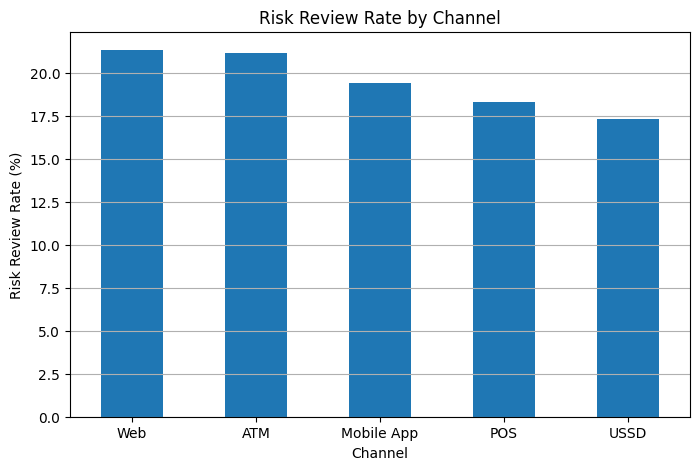


6. Transaction Failure Rate by Channel
Channel
Mobile App    5.80
USSD          5.40
POS           5.22
Web           4.71
ATM           4.18
Name: Transaction_Status, dtype: float64


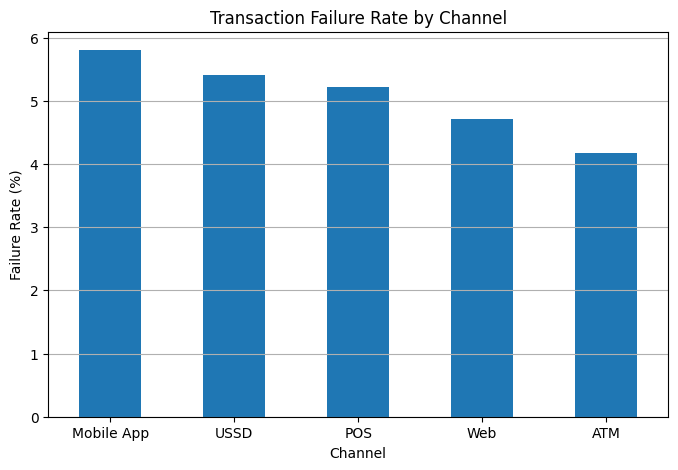


7. Risk Review Rate by Transaction Type
Transaction_Type
Transfer           28.49
Cash Withdrawal    25.31
Deposit            16.19
Airtime/Data       15.19
Card Purchase      13.02
Bill Payment       12.81
Name: Risk_Review_Flag, dtype: float64


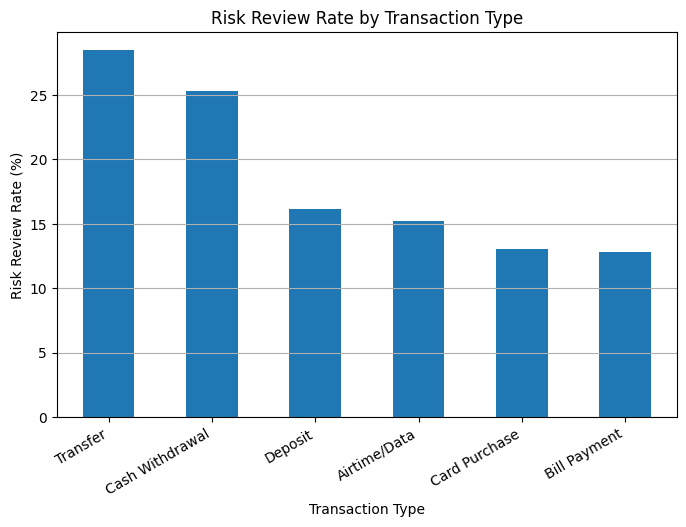


8. Monthly Transaction Volume
Transaction_Date
2026-01-31    4133
2026-02-28    3734
2026-03-31    4133
Freq: ME, dtype: int64


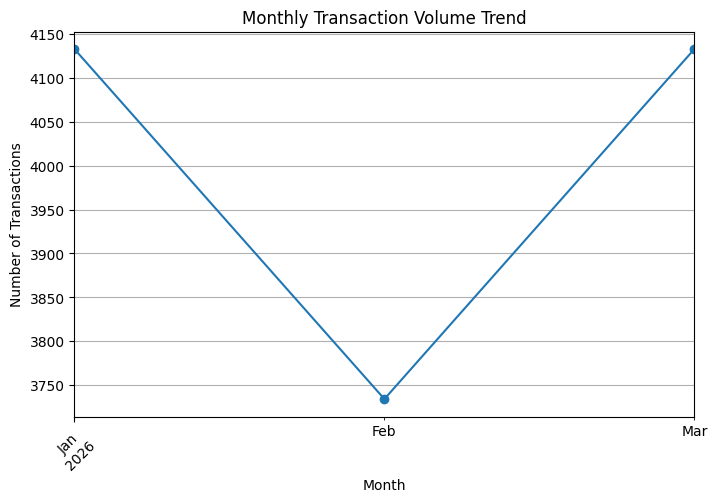


9. Monthly Transaction Value
Transaction_Date
2026-01-31    1.884894e+08
2026-02-28    1.757869e+08
2026-03-31    1.962010e+08
Freq: ME, Name: Amount_NGN, dtype: float64


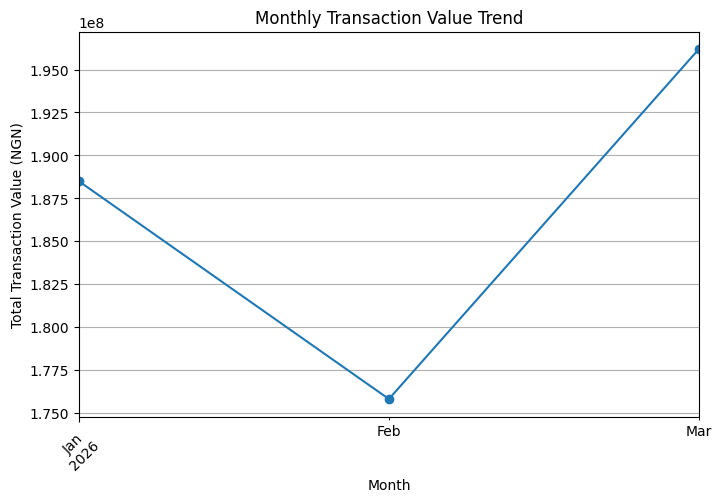


10. Customer Segment Transaction Analysis
                  Customers  Total_Transactions  Total_Transaction_Value  \
Customer_Segment                                                           
Everyday                711                5644             2.614589e+08   
Premium                 295                2361             1.077512e+08   
SME                     216                1706             8.379137e+07   
Student                 278                2289             1.074759e+08   

                  Avg_Transactions_Per_Customer  Avg_Value_Per_Customer  \
Customer_Segment                                                          
Everyday                                   7.94               367734.07   
Premium                                    8.00               365258.29   
SME                                        7.90               387923.02   
Student                                    8.23               386603.84   

                  Avg_Transaction_Value  
Custome

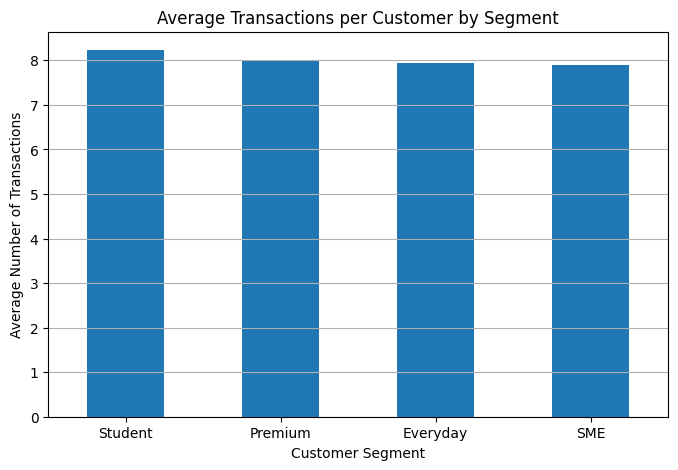

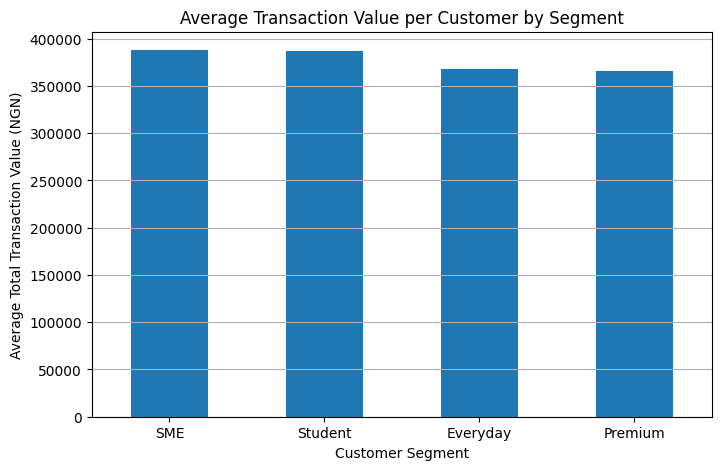


11. Risk Review Rate by Customer Segment
Customer_Segment
Premium     20.33
Student     19.75
SME         19.40
Everyday    19.29
Name: Risk_Review_Flag, dtype: float64


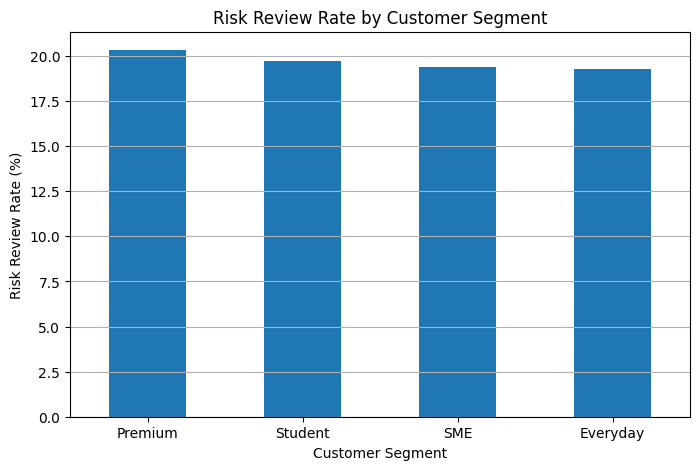


12. Validation of Week 2 Risk Review Finding
Total transactions: 12,000
Risk-reviewed transactions: 2,352
Risk review rate: 19.60%

Week 2 reported approximately 19.6%.
Week 3 calculated: 19.60%

13. Validation of Customer Segment Distribution
                  Customer_Count  Percentage
Customer_Segment                            
Everyday                     711       47.40
Premium                      295       19.67
Student                      278       18.53
SME                          216       14.40

14. Week 3 Analytical Summary
                                              Metric      Value
0                                    Total Customers   1500.000
1                                 Total Transactions  12000.000
2                         Average Transaction Amount  46706.446
3                          Median Transaction Amount  10305.935
4                                   Risk Review Rate     19.600
5                            Failed Transaction Rate      5.250
6  Dig

In [3]:
# ============================================================
# FINTRUST — WEEK 3 ADVANCED PYTHON ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0. LOAD DATA
# ------------------------------------------------------------

customers = pd.read_csv(
    "FinTrust_Customer_Data - FinTrust_Customer_Data.csv"
)

transactions = pd.read_csv(
    "FinTrust_Transaction_Data - FinTrust_Transaction_Data.csv"
)

# Convert transaction date/time to datetime
transactions['Transaction_Date'] = pd.to_datetime(
    transactions['Transaction_DateTime']
)

# Sort transactions chronologically
transactions = transactions.sort_values('Transaction_Date')

plt.rcParams['figure.figsize'] = (8, 5)


# ============================================================
# 1. CUSTOMER ENGAGEMENT VS TRANSACTION COUNT
# ============================================================
# Question:
# Are more digitally engaged customers more active?

# Calculate transaction activity for each customer
customer_activity = (
    transactions
    .groupby('Customer_ID')
    .agg(
        Transaction_Count=('Amount_NGN', 'size'),
        Total_Transaction_Value=('Amount_NGN', 'sum'),
        Average_Transaction_Value=('Amount_NGN', 'mean')
    )
    .reset_index()
)

# Combine customer information with transaction activity
customer_analysis = customers.merge(
    customer_activity,
    on='Customer_ID',
    how='left'
)

# Check for missing transaction activity
customer_analysis[
    ['Transaction_Count',
     'Total_Transaction_Value',
     'Average_Transaction_Value']
] = customer_analysis[
    ['Transaction_Count',
     'Total_Transaction_Value',
     'Average_Transaction_Value']
].fillna(0)

# Calculate Pearson correlation
engagement_transaction_corr = customer_analysis[
    ['Digital_Engagement_Score', 'Transaction_Count']
].corr().iloc[0, 1]

print("1. Digital Engagement vs Transaction Count")
print(
    f"Pearson correlation: "
    f"{engagement_transaction_corr:.3f}"
)

# Scatter plot
plt.figure()

plt.scatter(
    customer_analysis['Digital_Engagement_Score'],
    customer_analysis['Transaction_Count'],
    alpha=0.5
)

plt.title('Digital Engagement vs Transaction Activity')
plt.xlabel('Digital Engagement Score')
plt.ylabel('Number of Transactions')

plt.grid(axis='y')
plt.show()


# ============================================================
# 2. DIGITAL ENGAGEMENT VS TOTAL TRANSACTION VALUE
# ============================================================
# Question:
# Does higher digital engagement correspond to higher
# transaction value?

engagement_value_corr = customer_analysis[
    ['Digital_Engagement_Score',
     'Total_Transaction_Value']
].corr().iloc[0, 1]

print("\n2. Digital Engagement vs Total Transaction Value")
print(
    f"Pearson correlation: "
    f"{engagement_value_corr:.3f}"
)

plt.figure()

plt.scatter(
    customer_analysis['Digital_Engagement_Score'],
    customer_analysis['Total_Transaction_Value'],
    alpha=0.5
)

plt.title('Digital Engagement vs Total Transaction Value')
plt.xlabel('Digital Engagement Score')
plt.ylabel('Total Transaction Value (NGN)')

plt.grid(axis='y')
plt.show()


# ============================================================
# 3. CORRELATION MATRIX
# ============================================================
# Examine relationships between several customer-level
# numerical variables.

correlation_matrix = customer_analysis[
    [
        'Digital_Engagement_Score',
        'Transaction_Count',
        'Total_Transaction_Value',
        'Average_Transaction_Value'
    ]
].corr()

print("\n3. Customer-Level Correlation Matrix")
print(correlation_matrix.round(3))


# ============================================================
# 4. RISK REVIEW VS TRANSACTION AMOUNT
# ============================================================
# Question:
# Are risk-reviewed transactions associated with different
# transaction amounts?

risk_amount_summary = (
    transactions
    .groupby('Risk_Review_Flag')['Amount_NGN']
    .agg(
        Transaction_Count='count',
        Average_Amount='mean',
        Median_Amount='median'
    )
    .round(2)
)

print("\n4. Transaction Amount by Risk Review Status")
print(risk_amount_summary)

# Boxplot
plt.figure()

transactions.boxplot(
    column='Amount_NGN',
    by='Risk_Review_Flag'
)

plt.title('Transaction Amount by Risk Review Status')
plt.suptitle('')
plt.xlabel('Risk Review Flag')
plt.ylabel('Transaction Amount (NGN)')

plt.show()


# ============================================================
# 5. RISK REVIEW RATE BY CHANNEL
# ============================================================
# Question:
# Does the likelihood of risk review differ by channel?

risk_by_channel = (
    transactions
    .groupby('Channel')['Risk_Review_Flag']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print("\n5. Risk Review Rate by Channel")
print(risk_by_channel.round(2))

plt.figure()

risk_by_channel.plot(kind='bar')

plt.title('Risk Review Rate by Channel')
plt.xlabel('Channel')
plt.ylabel('Risk Review Rate (%)')

plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


# ============================================================
# 6. FAILURE RATE BY CHANNEL
# ============================================================
# Question:
# Does transaction reliability differ between channels?

failure_by_channel = (
    transactions
    .groupby('Channel')['Transaction_Status']
    .apply(lambda x: (x == 'Failed').mean() * 100)
    .sort_values(ascending=False)
)

print("\n6. Transaction Failure Rate by Channel")
print(failure_by_channel.round(2))

plt.figure()

failure_by_channel.plot(kind='bar')

plt.title('Transaction Failure Rate by Channel')
plt.xlabel('Channel')
plt.ylabel('Failure Rate (%)')

plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


# ============================================================
# 7. RISK REVIEW RATE BY TRANSACTION TYPE
# ============================================================
# Question:
# Are some transaction types reviewed for risk more frequently?

risk_by_type = (
    transactions
    .groupby('Transaction_Type')['Risk_Review_Flag']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print("\n7. Risk Review Rate by Transaction Type")
print(risk_by_type.round(2))

plt.figure()

risk_by_type.plot(kind='bar')

plt.title('Risk Review Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Risk Review Rate (%)')

plt.xticks(rotation=30, ha='right')
plt.grid(axis='y')
plt.show()


# ============================================================
# 8. MONTHLY TRANSACTION VOLUME TREND
# ============================================================
# Question:
# How does transaction activity change over time?

monthly_transactions = (
    transactions
    .set_index('Transaction_Date')
    .resample('ME')
    .size()
)

print("\n8. Monthly Transaction Volume")
print(monthly_transactions)

plt.figure()

monthly_transactions.plot(
    kind='line',
    marker='o'
)

plt.title('Monthly Transaction Volume Trend')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


# ============================================================
# 9. MONTHLY TRANSACTION VALUE TREND
# ============================================================
# Question:
# Does the total financial value of transactions change
# over time?

monthly_value = (
    transactions
    .set_index('Transaction_Date')['Amount_NGN']
    .resample('ME')
    .sum()
)

print("\n9. Monthly Transaction Value")
print(monthly_value.round(2))

plt.figure()

monthly_value.plot(
    kind='line',
    marker='o'
)

plt.title('Monthly Transaction Value Trend')
plt.xlabel('Month')
plt.ylabel('Total Transaction Value (NGN)')

plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()


# ============================================================
# 10. CUSTOMER SEGMENT ANALYSIS
# ============================================================
# Question:
# How do customer segments differ in actual transaction
# behaviour?

segment_analysis = customer_analysis.groupby(
    'Customer_Segment'
).agg(
    Customers=('Customer_ID', 'nunique'),
    Total_Transactions=('Transaction_Count', 'sum'),
    Total_Transaction_Value=('Total_Transaction_Value', 'sum'),
    Avg_Transactions_Per_Customer=('Transaction_Count', 'mean'),
    Avg_Value_Per_Customer=('Total_Transaction_Value', 'mean'),
    Avg_Transaction_Value=('Average_Transaction_Value', 'mean')
).round(2)

print("\n10. Customer Segment Transaction Analysis")
print(segment_analysis)


# Average transactions per customer
plt.figure()

segment_analysis[
    'Avg_Transactions_Per_Customer'
].sort_values(
    ascending=False
).plot(kind='bar')

plt.title('Average Transactions per Customer by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Number of Transactions')

plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


# Average transaction value per customer
plt.figure()

segment_analysis[
    'Avg_Value_Per_Customer'
].sort_values(
    ascending=False
).plot(kind='bar')

plt.title('Average Transaction Value per Customer by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Total Transaction Value (NGN)')

plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


# ============================================================
# 11. SEGMENT RISK REVIEW RATE
# ============================================================
# Question:
# Does risk-review activity differ across customer segments?

segment_risk = (
    transactions
    .merge(
        customers[['Customer_ID', 'Customer_Segment']],
        on='Customer_ID',
        how='left'
    )
    .groupby('Customer_Segment')['Risk_Review_Flag']
    .apply(lambda x: (x == 'Yes').mean() * 100)
    .sort_values(ascending=False)
)

print("\n11. Risk Review Rate by Customer Segment")
print(segment_risk.round(2))

plt.figure()

segment_risk.plot(kind='bar')

plt.title('Risk Review Rate by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Risk Review Rate (%)')

plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()


# ============================================================
# 12. VALIDATION OF WEEK 2 RISK FINDING
# ============================================================
# Week 2 finding:
# Approximately 20% of transactions were flagged for risk review.
#
# Here we calculate the exact percentage again.

total_transactions = len(transactions)

flagged_transactions = (
    transactions['Risk_Review_Flag'] == 'Yes'
).sum()

risk_rate = (
    flagged_transactions / total_transactions
) * 100

print("\n12. Validation of Week 2 Risk Review Finding")
print(f"Total transactions: {total_transactions:,}")
print(f"Risk-reviewed transactions: {flagged_transactions:,}")
print(f"Risk review rate: {risk_rate:.2f}%")

print("\nWeek 2 reported approximately 19.6%.")
print(f"Week 3 calculated: {risk_rate:.2f}%")


# ============================================================
# 13. VALIDATION OF WEEK 2 SEGMENT SIZE FINDING
# ============================================================
# Re-check the customer segment distribution.

segment_counts = (
    customers['Customer_Segment']
    .value_counts()
)

segment_percentages = (
    customers['Customer_Segment']
    .value_counts(normalize=True) * 100
)

segment_validation = pd.DataFrame({
    'Customer_Count': segment_counts,
    'Percentage': segment_percentages.round(2)
})

print("\n13. Validation of Customer Segment Distribution")
print(segment_validation)


# ============================================================
# 14. SUMMARY TABLE FOR IMPORTANT METRICS
# ============================================================

summary = pd.DataFrame({
    'Metric': [
        'Total Customers',
        'Total Transactions',
        'Average Transaction Amount',
        'Median Transaction Amount',
        'Risk Review Rate',
        'Failed Transaction Rate',
        'Digital Engagement vs Transaction Count Correlation',
        'Digital Engagement vs Transaction Value Correlation'
    ],
    'Value': [
        len(customers),
        len(transactions),
        transactions['Amount_NGN'].mean(),
        transactions['Amount_NGN'].median(),
        risk_rate,
        (transactions['Transaction_Status'] == 'Failed').mean() * 100,
        engagement_transaction_corr,
        engagement_value_corr
    ]
})

print("\n14. Week 3 Analytical Summary")
print(summary.round(3))